In [137]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
import tarfile
import pickle
import os

In [138]:
def load_cifar10_manual(file_path):
    with tarfile.open(file_path, "r:gz") as tar:
        tar.extractall()

    def unpickle(file):
        with open(file, 'rb') as fo:
            dict_data = pickle.load(fo, encoding='bytes')
        return dict_data

    x_train_list = []
    y_train_list = []
    for i in range(1, 6):
        batch = unpickle(f'cifar-10-batches-py/data_batch_{i}')
        x_train_list.append(batch[b'data'])
        y_train_list.append(batch[b'labels'])
        
    test_batch = unpickle('cifar-10-batches-py/test_batch')
    x_test = test_batch[b'data']
    y_test = np.array(test_batch[b'labels'])

    x_train = np.concatenate(x_train_list)
    x_train = x_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    
    y_train = np.concatenate(y_train_list)
    
    x_test = x_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    return (x_train, y_train), (x_test, y_test)

(x_train, y_train), (x_test, y_test) = load_cifar10_manual('cifar-10-python.tar.gz')

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape) 


C:\Users\Erfan\AppData\Local\Temp\ipykernel_25428\1327816814.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


x_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)


In [139]:
x_train

array([[[[ 59,  62,  63],
         [ 43,  46,  45],
         [ 50,  48,  43],
         ...,
         [158, 132, 108],
         [152, 125, 102],
         [148, 124, 103]],

        [[ 16,  20,  20],
         [  0,   0,   0],
         [ 18,   8,   0],
         ...,
         [123,  88,  55],
         [119,  83,  50],
         [122,  87,  57]],

        [[ 25,  24,  21],
         [ 16,   7,   0],
         [ 49,  27,   8],
         ...,
         [118,  84,  50],
         [120,  84,  50],
         [109,  73,  42]],

        ...,

        [[208, 170,  96],
         [201, 153,  34],
         [198, 161,  26],
         ...,
         [160, 133,  70],
         [ 56,  31,   7],
         [ 53,  34,  20]],

        [[180, 139,  96],
         [173, 123,  42],
         [186, 144,  30],
         ...,
         [184, 148,  94],
         [ 97,  62,  34],
         [ 83,  53,  34]],

        [[177, 144, 116],
         [168, 129,  94],
         [179, 142,  87],
         ...,
         [216, 184, 140],
        

$$Mean\_Image_{x,y,c} = \frac{1}{N} \sum_{i=1}^{N} I(i, x, y, c)$$

In [140]:
x_train = x_train.astype(np.float64)
mean_img = np.sum(x_train, axis=0)/x_train.shape[0]
mean_img

array([[[130.71074, 136.05614, 132.5538 ],
        [130.14036, 135.44238, 131.85358],
        [131.05044, 136.24616, 132.58144],
        ...,
        [131.05902, 136.307  , 132.44078],
        [130.39308, 135.70848, 132.00036],
        [130.174  , 135.4736 , 131.89246]],

       [[130.0993 , 135.29484, 131.36412],
        [129.3446 , 134.45914, 130.4656 ],
        [130.2169 , 135.1767 , 131.10234],
        ...,
        [130.04254, 135.13862, 130.90018],
        [129.33038, 134.55898, 130.49918],
        [129.1568 , 134.38368, 130.45104]],

       [[129.72472, 134.64818, 130.2514 ],
        [128.71662, 133.49748, 129.01922],
        [129.47348, 134.05546, 129.47586],
        ...,
        [129.21066, 133.95824, 129.29398],
        [128.59094, 133.54152, 129.06528],
        [128.59134, 133.55772, 129.22356]],

       ...,

       [[126.55372, 125.9533 , 114.1421 ],
        [124.58844, 123.7335 , 111.77894],
        [123.92508, 122.8011 , 110.73544],
        ...,
        [124.24036, 123.00

In [141]:
np.mean(x_train, axis=0)

array([[[130.71074, 136.05614, 132.5538 ],
        [130.14036, 135.44238, 131.85358],
        [131.05044, 136.24616, 132.58144],
        ...,
        [131.05902, 136.307  , 132.44078],
        [130.39308, 135.70848, 132.00036],
        [130.174  , 135.4736 , 131.89246]],

       [[130.0993 , 135.29484, 131.36412],
        [129.3446 , 134.45914, 130.4656 ],
        [130.2169 , 135.1767 , 131.10234],
        ...,
        [130.04254, 135.13862, 130.90018],
        [129.33038, 134.55898, 130.49918],
        [129.1568 , 134.38368, 130.45104]],

       [[129.72472, 134.64818, 130.2514 ],
        [128.71662, 133.49748, 129.01922],
        [129.47348, 134.05546, 129.47586],
        ...,
        [129.21066, 133.95824, 129.29398],
        [128.59094, 133.54152, 129.06528],
        [128.59134, 133.55772, 129.22356]],

       ...,

       [[126.55372, 125.9533 , 114.1421 ],
        [124.58844, 123.7335 , 111.77894],
        [123.92508, 122.8011 , 110.73544],
        ...,
        [124.24036, 123.00

$$Mean\_Intensity_{x,y,c} = \frac{\sum_{i=1}^{50000} \sum_{x=1}^{32} \sum_{y=1}^{32} I(i, x, y, c)}{50000 \times 32 \times 32}$$


In [142]:
pixels_per_channel = x_train.shape[0]*x_train.shape[1]*x_train.shape[2]
print(pixels_per_channel)
sum_per_channel = np.sum(x_train, axis=(0,1,2))
print(sum_per_channel)
mean_intensity = sum_per_channel / pixels_per_channel
mean_intensity

51200000
[6.41571420e+09 6.29506018e+09 5.82990762e+09]


array([125.30691805, 122.95039414, 113.86538318])

In [143]:
np.mean(x_train, axis=(0,1,2))

array([125.30691805, 122.95039414, 113.86538318])

$$\sigma^2 = \frac{1}{N} \sum (x_i - \mu)^2$$

In [144]:
variance = np.sum((x_train-mean_intensity)**2, axis=(0,1,2)) / pixels_per_channel
variance

array([3968.14567502, 3855.00761641, 4449.54363607])

In [145]:
np.var(x_train, axis=(0,1,2))

array([3968.14567502, 3855.00761641, 4449.54363607])

In [146]:
standard_deviation = np.sqrt(variance)
standard_deviation

array([62.99321928, 62.08870764, 66.70489964])

In [147]:
np.std(x_train, axis=(0,1,2))

array([62.99321928, 62.08870764, 66.70489964])

In [148]:
index = np.random.randint(1,50000)
sample_image = x_train[index]

print(sample_image.shape)
sample_image_flatten = sample_image.flatten()
print(sample_image_flatten.shape)


(32, 32, 3)
(3072,)


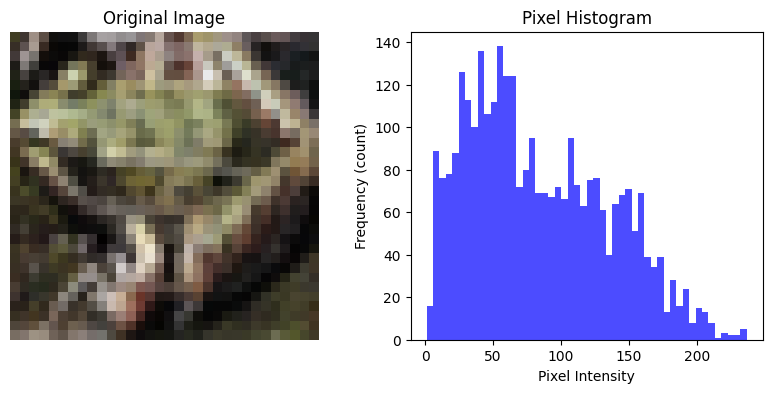

In [149]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

axes[0].imshow(sample_image.astype(np.uint8))
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].hist(sample_image_flatten, bins=50, color='blue', alpha=0.7)
axes[1].set_title("Pixel Histogram")
axes[1].set_xlabel("Pixel Intensity")
axes[1].set_ylabel("Frequency (count)")

plt.show()

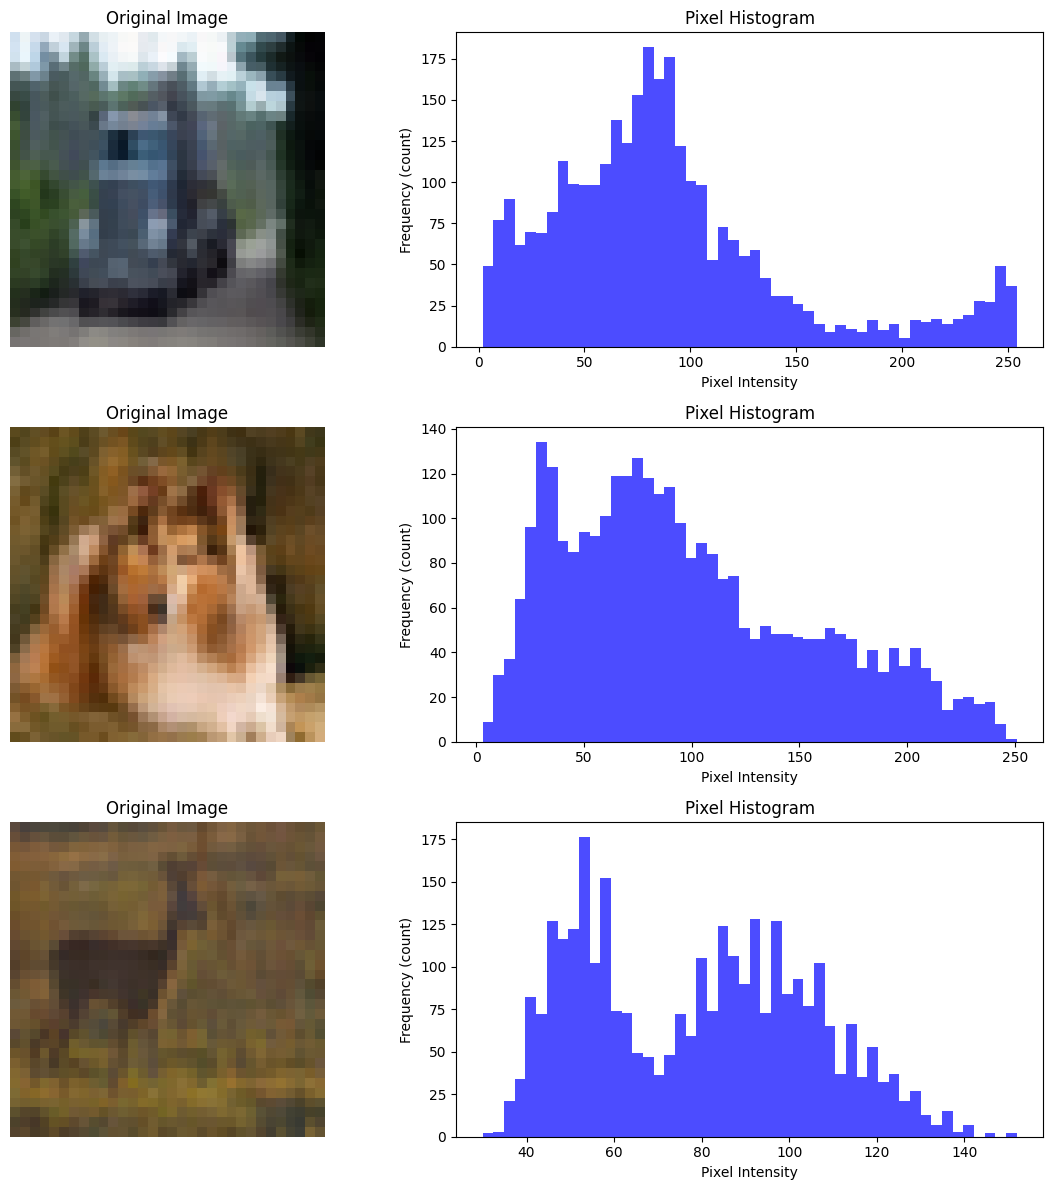

In [150]:
indices = np.random.choice(len(x_train), 3, replace=False)

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for i, idx in enumerate(indices):
    img = x_train[idx]
    img_flatten = img.flatten()
    
    axes[i,0].imshow(img.astype(np.uint8))
    axes[i,0].set_title("Original Image")
    axes[i,0].axis('off')

    axes[i,1].hist(img_flatten, bins=50, color='blue', alpha=0.7)
    axes[i,1].set_title("Pixel Histogram")
    axes[i,1].set_xlabel("Pixel Intensity")
    axes[i,1].set_ylabel("Frequency (count)")
    
plt.tight_layout()
plt.show()
    

Scale 10 -> Mean: 83.42, Variance: 2706.59
Scale 25 -> Mean: 83.28, Variance: 3126.21
Scale 50 -> Mean: 86.76, Variance: 4205.82


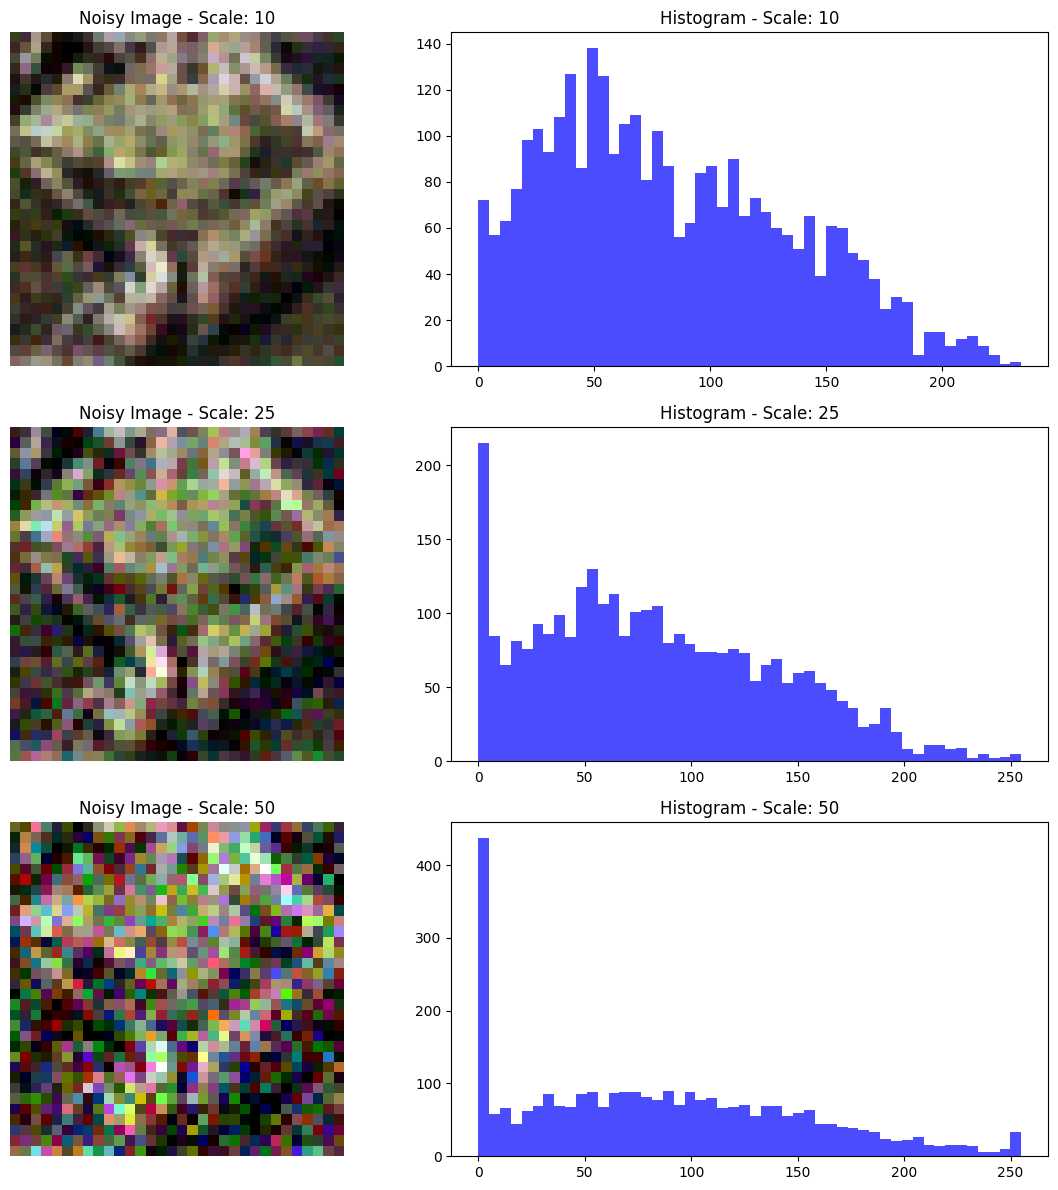

In [156]:
scales = [10, 25, 50]
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for i, scale in enumerate(scales):
    noise_image = np.random.normal(loc=0, scale=scale, size=sample_image.shape)
    
    noisy_sample = sample_image + noise_image
    
    noisy_sample_clipped = np.clip(noisy_sample, 0, 255).astype(np.uint8)
    noisy_sample_flatten = noisy_sample_clipped.flatten()
    
    axes[i, 0].imshow(noisy_sample_clipped)
    axes[i, 0].set_title(f"Noisy Image - Scale: {scale}")
    axes[i, 0].axis('off')
    
    axes[i, 1].hist(noisy_sample_flatten, bins=50, color='blue', alpha=0.7)
    axes[i, 1].set_title(f"Histogram - Scale: {scale}")
    print(f"Scale {scale} -> Mean: {np.mean(noisy_sample_clipped):.2f}, Variance: {np.var(noisy_sample_clipped):.2f}")
    

plt.tight_layout()
plt.show()


**رابطه ریاضی کانولوشن دو بعدی:**<br>
برای تصویر $I$ و کرنل $K$، مقدار پیکسل خروجی در مختصات $(i, j)$ از رابطه زیر محاسبه می‌شود:
$$S(i,j) = (I * K)(i,j) = \sum_m \sum_n I(i+m, j+n) K(m, n)$$

In [ ]:
def manual_convolution(image, kernel):
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape
    out_h = img_h - k_h + 1
    out_w = img_w - k_w + 1
    
    output = np.zeros((out_h, out_w))

Scale 50 -> Mean: 86.07, Variance: 4212.77
